In [10]:
# Add import 
import sys
import torch 
from torch import nn
from torch import optim
import tqdm
import numpy as np
import matplotlib.pyplot as plt
# allow reload of python modules
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
from dataset.RobotPathDataset.normalizer import MinMaxFeatureNormalizer

from model.models import EMA
import copy
from dataset import RobotPathDataset
from model.loss import WeightedLoss, ObstacleFreePathLoss

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
normalizer = MinMaxFeatureNormalizer()
encoder_normalizer = MinMaxFeatureNormalizer()
CONFIG = {
    # Model configuration
    'representation_dim': 64,
    # Hyperparameters for training
    'batch_size': 32,
    'num_epochs': 100,
    'learning_rate': 0.001,
    'optimizer': optim.Adam,
    # Hyperparameters for diffusion process
    'noise_steps': 100,
    'normalize': True,
    'normalizer':normalizer,
    'encoder_normalizer':encoder_normalizer,
    'scheduler': optim.lr_scheduler.ExponentialLR,
    'ema': EMA(0.99),
    'scheduler_gamma': 0.999,

    # Dataset specific configuration
    'n_paths_per_world': 100,
    'n_worlds': 1,
    'n_waypoints': 20,
}

In [12]:
file = 'D:\Desktop\ADLR\RobotPathData\data\SingleSphere02_all.db'
dataset = RobotPathDataset(file, n_paths_per_world=CONFIG['n_paths_per_world'], n_worlds=CONFIG['n_worlds'],  n_waypoints=CONFIG['n_waypoints'],   normalizer=CONFIG['normalizer'])
print(f' sample shape {dataset[0]["path"].shape} with {len(dataset)} samples')
indx_sample = 5
sample = dataset[indx_sample]

world_indx: 14, world_distance_field_images: torch.Size([64, 64])
data shape: torch.Size([100, 20, 2]), min_values: tensor([0, 0], device='cuda:0'), max_values: tensor([10, 10], device='cuda:0'), n_worlds:1, samples: 100
 sample shape torch.Size([20, 2]) with 100 samples


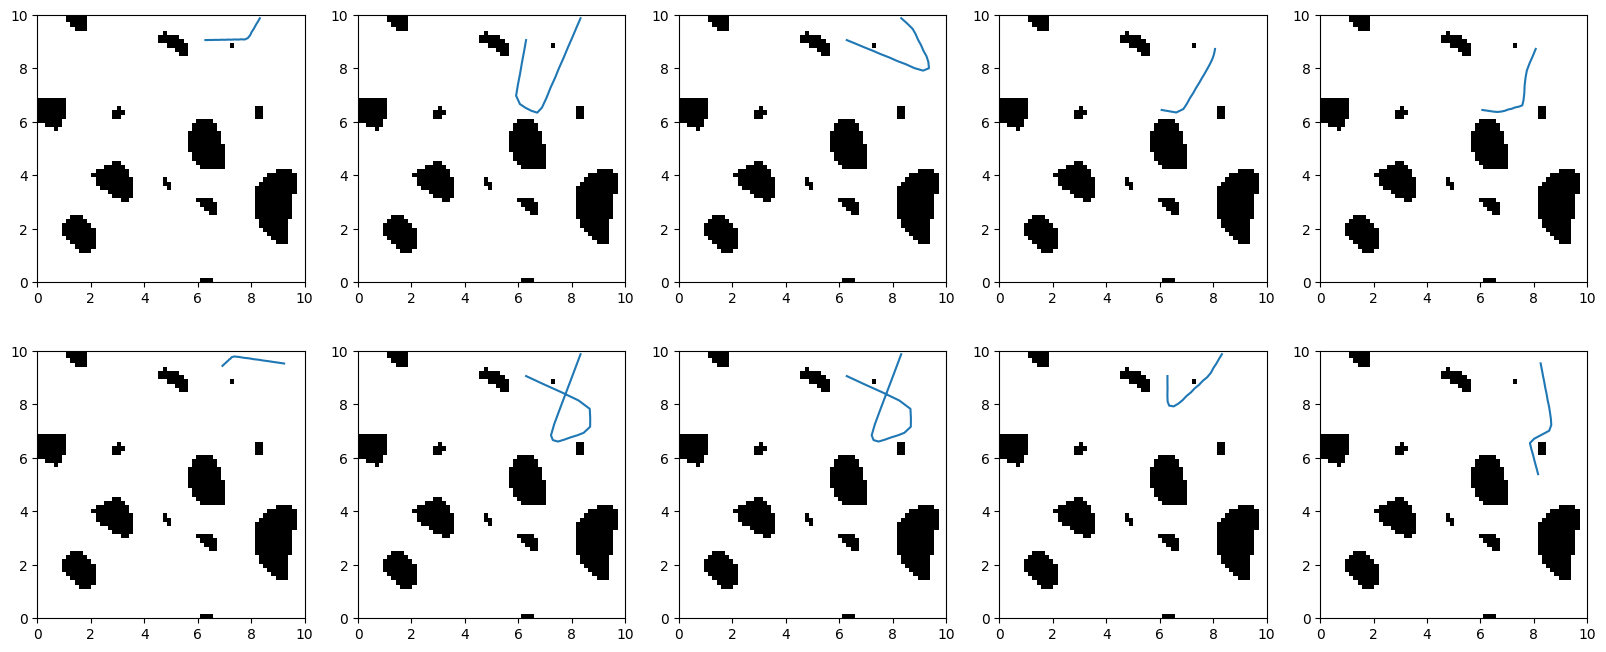

In [13]:
# plot 10 random index samples
fig, axs = plt.subplots(2, 5, figsize=(20, 8))
for i in range(2):
    for j in range(5):
        indx = np.random.randint(len(dataset))
        sample = dataset[indx]
        sample['path'] = CONFIG['normalizer'].denormalize(sample['path']).cpu().numpy()
        sample['world_img'] = sample['world_img']
        axs[i, j].plot(sample['path'][:, 0], sample['path'][:, 1])
        axs[i, j].imshow(sample['world_img'].T, extent=[0, 10, 0, 10], origin='lower', cmap='binary')


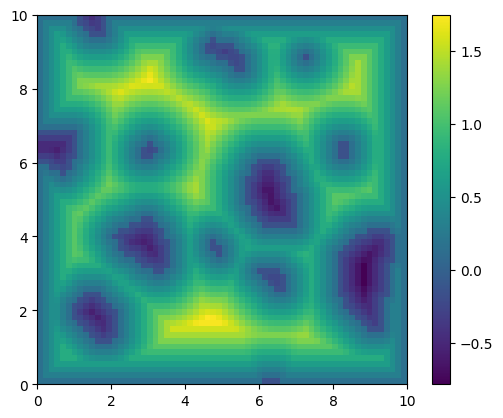

In [14]:
sample = dataset[indx]
dimg = sample['world_distance_field_img']
plt.imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
# show the value of colors 
plt.colorbar()

In [15]:
dimg

tensor([[0.1562, 0.1562, 0.1562,  ..., 0.1562, 0.1562, 0.1562],
        [0.1562, 0.3125, 0.3125,  ..., 0.3125, 0.3125, 0.1562],
        [0.1562, 0.3125, 0.4688,  ..., 0.4688, 0.3125, 0.1562],
        ...,
        [0.1562, 0.3125, 0.4688,  ..., 0.4688, 0.3125, 0.1562],
        [0.1562, 0.3125, 0.3125,  ..., 0.3125, 0.3125, 0.1562],
        [0.1562, 0.1562, 0.1562,  ..., 0.1562, 0.1562, 0.1562]])

## Analyse nature of dimg

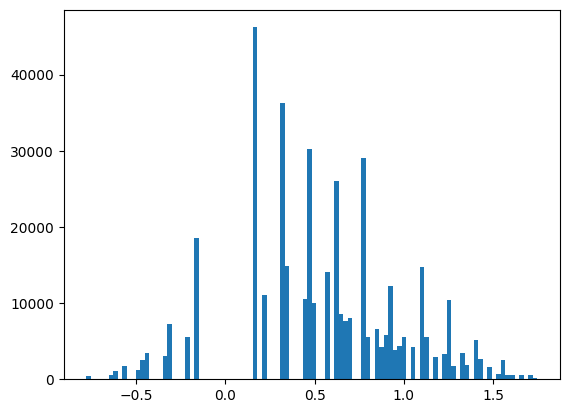

In [16]:
# get hostogram of values 
# sample many points from the dataset
values = []
for i in range(100):
    indx = np.random.randint(len(dataset))
    sample = dataset[indx]
    dimg = sample['world_distance_field_img']
    values.extend(dimg.flatten());
plt.hist(values, bins=100);

In [17]:
normalizer = MinMaxFeatureNormalizer()
# min_values are a 64 * 64 array filled with -1
min_values = np.ones((64, 64)) * -1
# max_values are a 64 * 64 array filled with 3.5
max_values = np.ones((64, 64)) * 3.5
normalizer.initialize(min_values=min_values, max_values=max_values)

C:\Users\karim lotfy\AppData\Local\Temp\ipykernel_6060\3545446736.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dimg = torch.tensor(dimg, device='cuda').float()


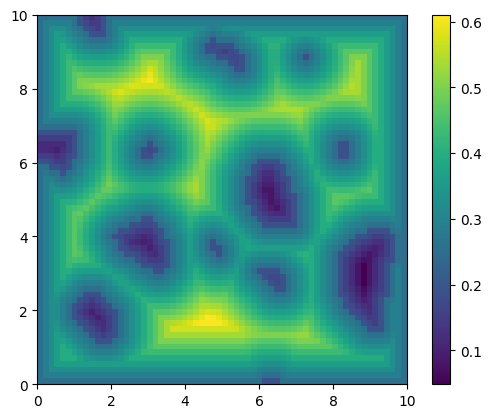

In [18]:
# try to normalize the values using torch layernorm
dimg = torch.tensor(dimg, device='cuda').float()
dimg = normalizer.normalize(dimg)
dimg = dimg.flatten()
dimg = dimg.reshape(64, 64)
plt.imshow(dimg.cpu().detach().numpy().T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
plt.colorbar()

C:\Users\karim lotfy\AppData\Local\Temp\ipykernel_6060\909360617.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dimg = torch.tensor(dimg, device='cuda').float()


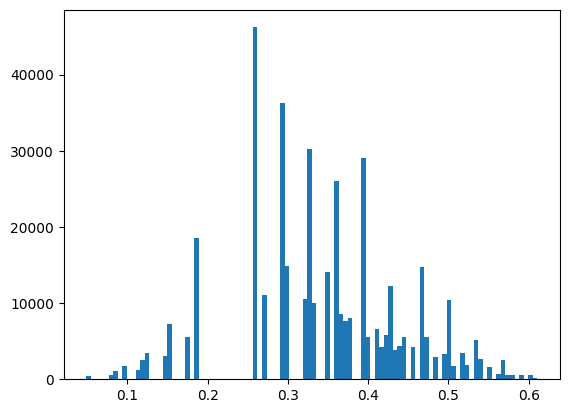

In [19]:
# get hostogram of values 
# sample many points from the dataset
values = []
for i in range(100):
    indx = np.random.randint(len(dataset))
    sample = dataset[indx]
    dimg = sample['world_distance_field_img']
    # try to normalize the values using torch layernorm
    dimg = torch.tensor(dimg, device='cuda').float()
    dimg = normalizer.normalize(dimg)
    dimg = dimg.flatten()
    dimg = dimg.cpu().detach().numpy()
    values.extend(dimg);
plt.hist(values, bins=100);

C:\Users\karim lotfy\AppData\Local\Temp\ipykernel_6060\3981840068.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dimg = torch.tensor(dimg).float()


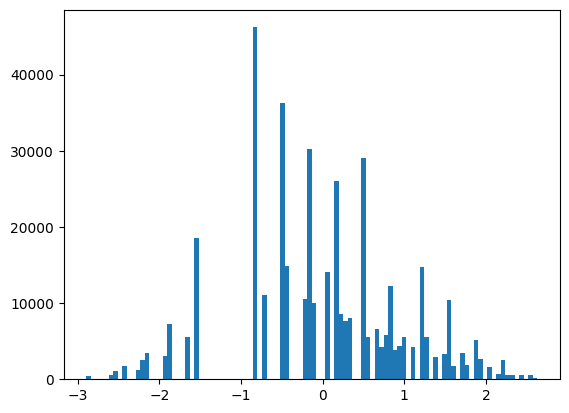

In [20]:
# get hostogram of values 
# sample many points from the dataset
values = []
for i in range(100):
    indx = np.random.randint(len(dataset))
    sample = dataset[indx]
    dimg = sample['world_distance_field_img']
    # try to normalize the values using torch layernorm
    dimg = torch.tensor(dimg).float()
    norm = nn.LayerNorm(dimg.shape)
    dimg = norm(dimg)
    dimg = dimg.flatten()
    dimg = dimg.cpu().detach().numpy()
    values.extend(dimg);
plt.hist(values, bins=100);

112


IndexError: index 112 is out of bounds for dimension 0 with size 100

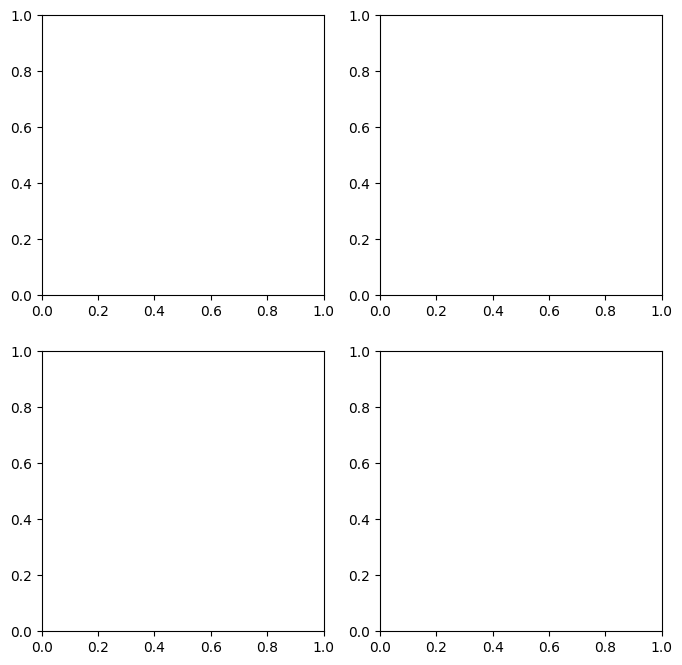

In [21]:
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
indx = 112
print(indx)
sample = dataset[indx]
sample['path'] = CONFIG['normalizer'].denormalize(sample['path']).cpu().numpy()
sample = dataset.get_og_item(indx)
sample['path'] = sample['path'].cpu().numpy()
sample['world_img'] = sample['world_img']
axs[0, 0].plot(sample['path'][:, 0], sample['path'][:, 1], '-o')
axs[0, 0].imshow(sample['world_img'].T, extent=[-0, 10, -0, 10], origin='lower', cmap='binary')
fig.show()

# NEW LOSS FUNCTIONS

## ostacle free loss

In [ ]:
indx = np.random.randint(len(dataset))
# get a random sample 
sample = dataset[indx]
dimg = sample['world_distance_field_img']
plt.imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')

In [ ]:
# draw path on top of the distance field
path = sample['og_path'].cpu().detach().numpy()
plt.imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
plt.plot(path[:, 0], path[:, 1], '-o', color='red')

In [ ]:
loss = ObstacleFreePathLoss(normalizer=None)
indx = np.random.randint(len(dataset))
sample = dataset[indx]
dimg = sample['world_distance_field_img'].to('cuda')
path = sample['og_path']
path = path.unsqueeze(0)
dimg = dimg.unsqueeze(0)
l = loss(path, dimg)
l

In [ ]:
for i in range(10): # plot 10 paths and their distance field
    indx = np.random.randint(len(dataset))
    sample = dataset[indx]
    dimg = sample['world_distance_field_img'].to('cuda')
    path = sample['og_path']
    path = path.unsqueeze(0)
    dimg = dimg.unsqueeze(0)
    l = loss(path, dimg)
    dimg = sample['world_distance_field_img']
    path = sample['og_path'].cpu().detach().numpy()
    plt.imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
    plt.plot(path[:, 0], path[:, 1], '-o', color='red')
    plt.title(f'loss {l}')
    plt.show()

In [ ]:
for i in range(10):
    # create a subpolt for 2 graphs
    fig, axs = plt.subplots(1, 2, figsize=(16, 8))
    # the 1st will be the path and its distance field + loss value 
    indx = np.random.randint(len(dataset))
    sample = dataset[indx]
    dimg = sample['world_distance_field_img'].to('cuda')
    path = sample['og_path']
    path = path.unsqueeze(0)
    dimg = dimg.unsqueeze(0)
    l = loss(path, dimg)
    dimg = sample['world_distance_field_img']
    path = sample['og_path'].cpu().detach().numpy()
    axs[0].imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
    axs[0].plot(path[:, 0], path[:, 1], '-o', color='red')
    axs[0].set_title(f'loss {l}')
    # the 2nd will be the path + some noise and its distance field + loss value
    sample = dataset[indx]
    dimg = sample['world_distance_field_img'].to('cuda')
    path = sample['og_path']
    path = path.unsqueeze(0)
    dimg = dimg.unsqueeze(0)
    noise = torch.randn_like(path) * 0.8
    path = path + noise
    l = loss(path, dimg)
    dimg = sample['world_distance_field_img']
    path = path.cpu().detach().numpy()
    axs[1].imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
    axs[1].plot(path[0, :, 0], path[0, :, 1], '-o', color='red')
    axs[1].set_title(f'loss {l}')

In [ ]:

# create my own 2 point path
path = torch.tensor([[2, 6.1], [4, 4]], device='cuda').float()
path = path.unsqueeze(0)
path.requires_grad = True
dimg = sample['world_distance_field_img'].to('cuda')
dimg = dimg.unsqueeze(0)
l = loss(path, dimg)
dimg = sample['world_distance_field_img']
path_vis = path.cpu().detach().numpy()
plt.imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
plt.plot(path_vis[0, :, 0], path_vis[0, :, 1], '-o', color='red')
plt.title(f'loss {l}')

In [ ]:
# show the path after the optimization
dimg = sample['world_distance_field_img']
path_vis = path.cpu().detach().numpy()
plt.imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
plt.plot(path_vis[0, :, 0], path_vis[0, :, 1], '-o', color='red')
plt.title(f'path after optimization')

In [ ]:
# take 100 steps of optimization
optimizer = optim.Adam([path], lr=0.01)
for i in range(100):
    dimg = sample['world_distance_field_img'].to('cuda')
    dimg = dimg.unsqueeze(0)
    l = loss(path, dimg)
    optimizer.zero_grad()
    l.backward()
    optimizer.step()
    if i % 10 == 0:
        print(f'loss {l}')

In [ ]:
path

In [ ]:
# show the path after the optimization
dimg = sample['world_distance_field_img']
path_vis = path.cpu().detach().numpy()
plt.imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
plt.plot(path_vis[0, :, 0], path_vis[0, :, 1], '-o', color='red')
plt.title(f'path after optimization')

In [ ]:
path = torch.tensor([[2, 6.1], [4, 4]], device='cuda').float()
path = path.unsqueeze(0)
path.requires_grad = True
path_true_points = torch.tensor([[[4, 8], [6.5, 4.5]]], device='cuda').float()


In [ ]:
# take 100 steps of optimization
optimizer = optim.Adam([path], lr=0.01)
for i in range(100):
    dimg = sample['world_distance_field_img'].to('cuda')
    dimg = dimg.unsqueeze(0)
    l1 = loss(path, dimg)
    l2 = nn.MSELoss()(path, path_true_points)
    l = l1 + l2
    optimizer.zero_grad()
    l.backward()
    optimizer.step()
    if i % 10 == 0:
        print(f'loss {l}')

In [ ]:
# show the path after the optimization
dimg = sample['world_distance_field_img']
path_vis = path.cpu().detach().numpy()
plt.imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
plt.plot(path_vis[0, :, 0], path_vis[0, :, 1], '-o', color='red')
plt.title(f'path after optimization')

In [ ]:
path

## Loss for waypoint consitency

In [42]:
import torch
import torch.nn as nn

from model.loss import GraphBasedConsistencyLoss
loss_fn = GraphBasedConsistencyLoss()

In [46]:
import torch
import torch.nn as nn

class GraphBasedConsistencyLoss(nn.Module):
    def __init__(self, variance_weight=1.0):
        super(GraphBasedConsistencyLoss, self).__init__()
        self.variance_weight = variance_weight
    
    def forward(self, paths):
        """
        Args:
            paths (torch.Tensor): Tensor of shape (Batch, Waypoints, 2) where 2 is for (x, y) coordinates.
        
        Returns:
            torch.Tensor: The graph-based consistency loss with variance penalty.
        """
        # Compute the differences between consecutive waypoints
        differences = paths[:, 1:, :] - paths[:, :-1, :]
        
        # Compute the Euclidean distances for these differences
        distances = torch.norm(differences, dim=-1)
        
        # Compute the mean distance
        mean_distance = distances.mean(dim=-1, keepdim=True)
        
        # Compute the variance of the distances
        variance = ((distances - mean_distance) ** 2).mean(dim=-1)
        
        # Sum the distances to get the consistency loss
        consistency_loss = distances.sum(dim=-1).mean()
        
        # Compute the variance penalty
        variance_penalty = variance.mean()
        
        # Total loss
        # loss = consistency_loss + self.variance_weight * variance_penalty
        loss = variance_penalty
        
        return loss

# Example usage
if __name__ == "__main__":
    # Example paths tensor of shape (Batch, Waypoints, 2)
    paths = torch.tensor([[[0.0, 0.0], [1.0, 1.0], [2.0, 2.0]],
                          [[0.0, 1.0], [1.0, 2.0], [2.0, 3.0]]], dtype=torch.float32)
    
    # Initialize the loss function with a variance weight
    loss_fn = GraphBasedConsistencyLoss(variance_weight=1.0)
    
    # Compute the loss
    loss = loss_fn(paths)
    
    print("Graph-Based Consistency Loss with Variance Penalty:", loss.item())


Graph-Based Consistency Loss with Variance Penalty: 0.0


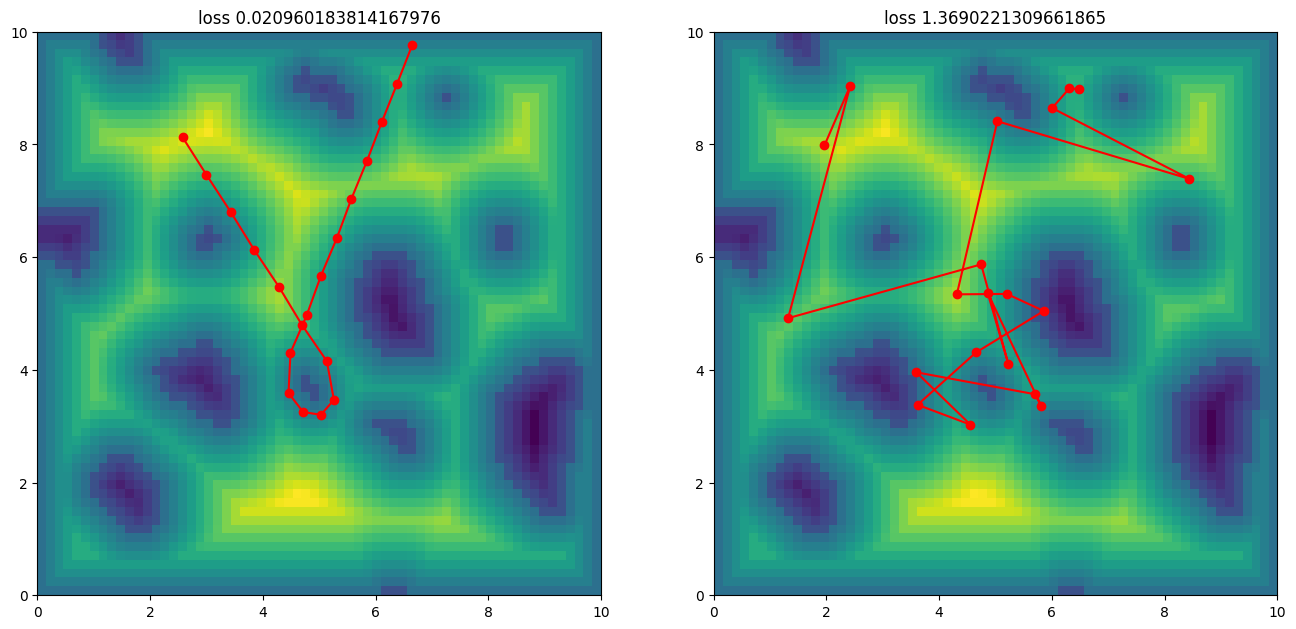

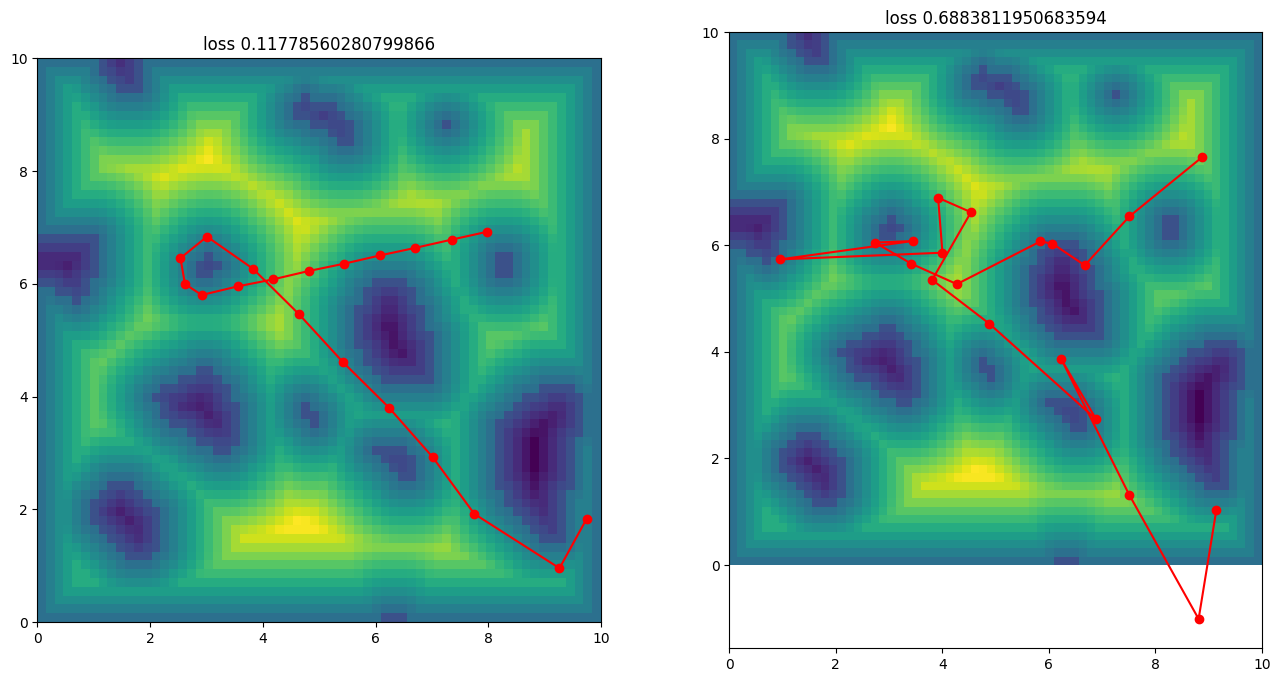

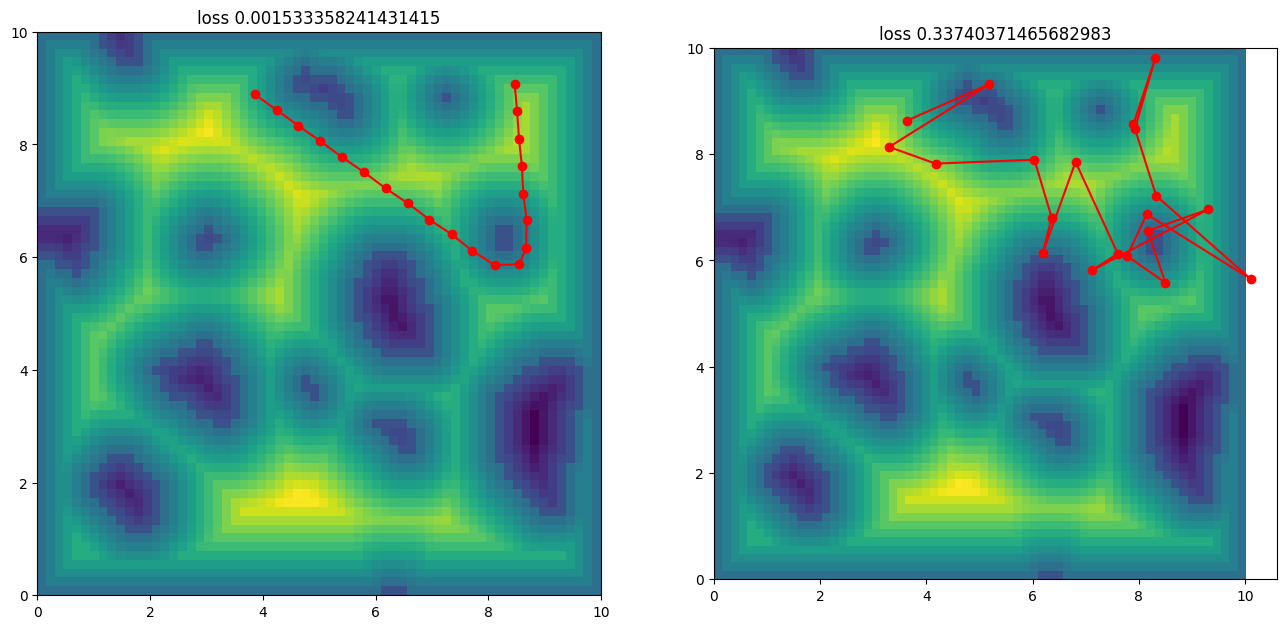

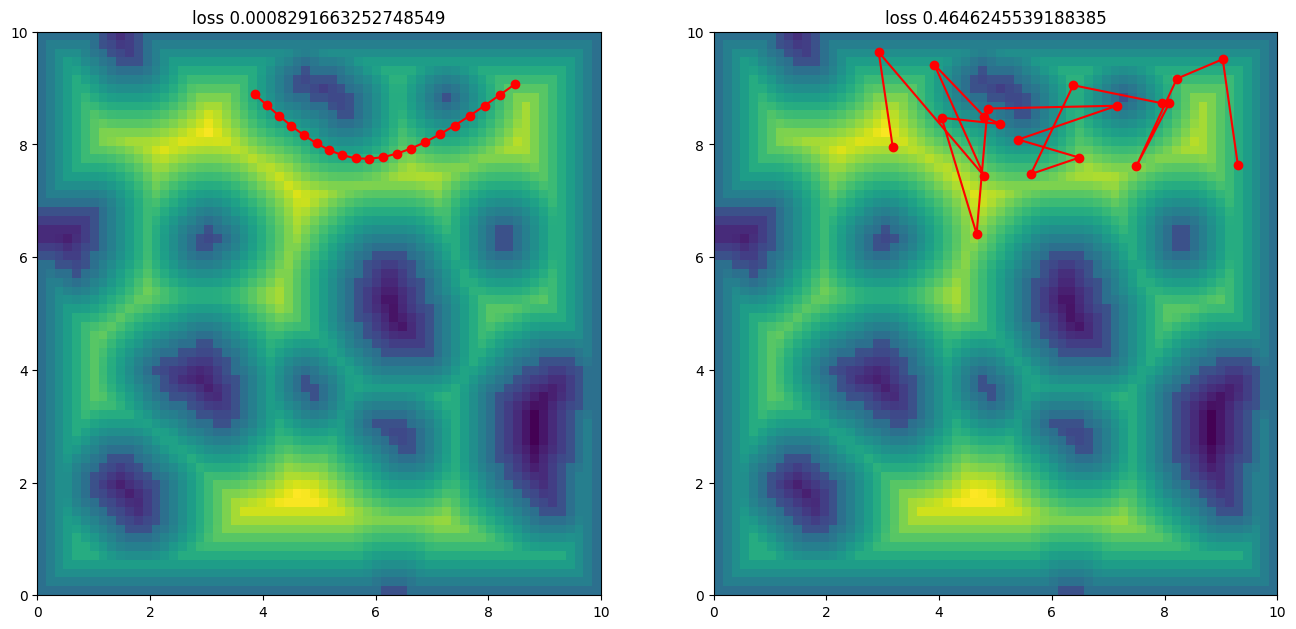

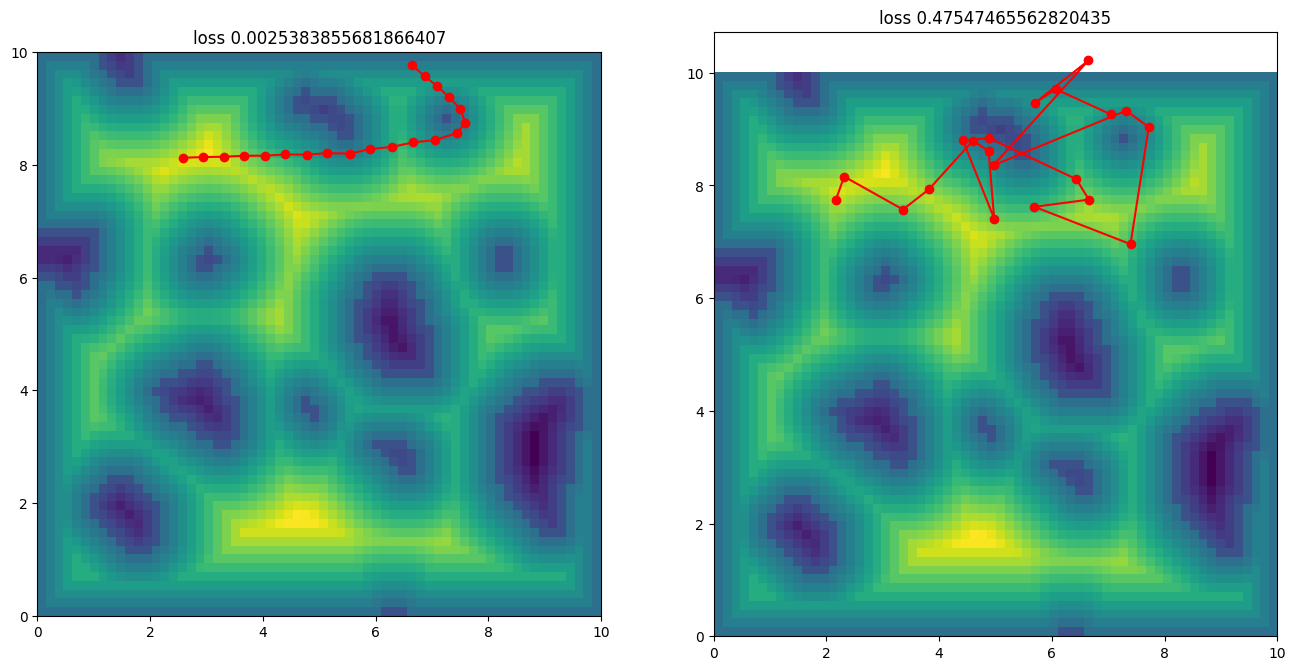

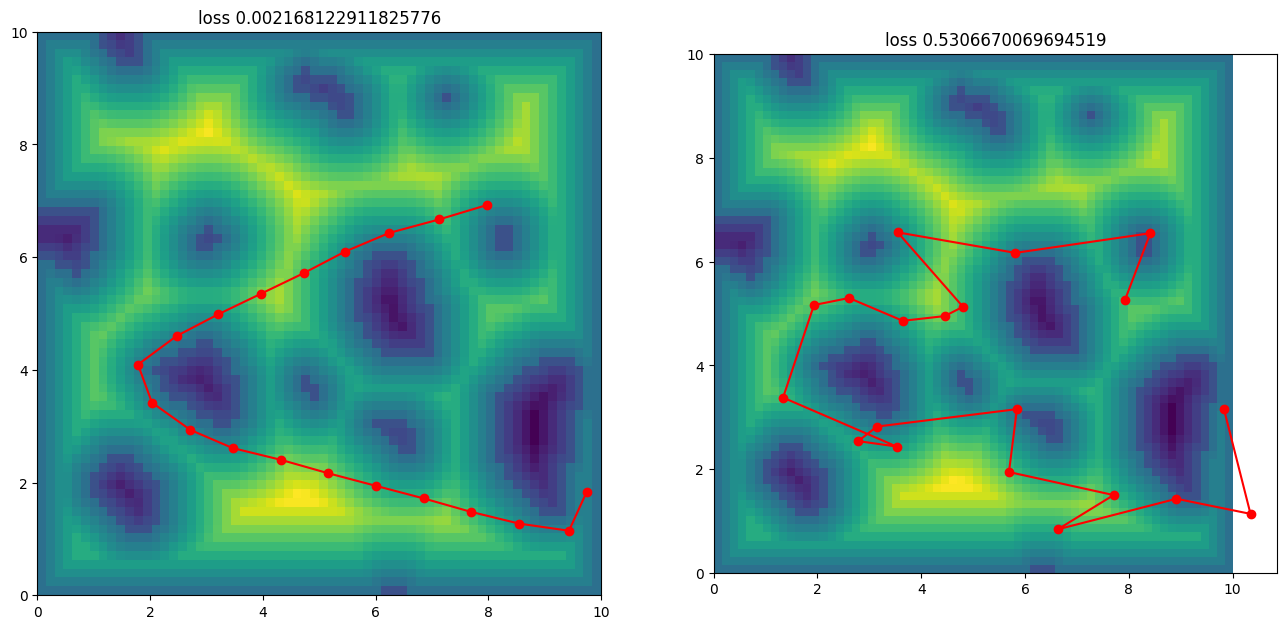

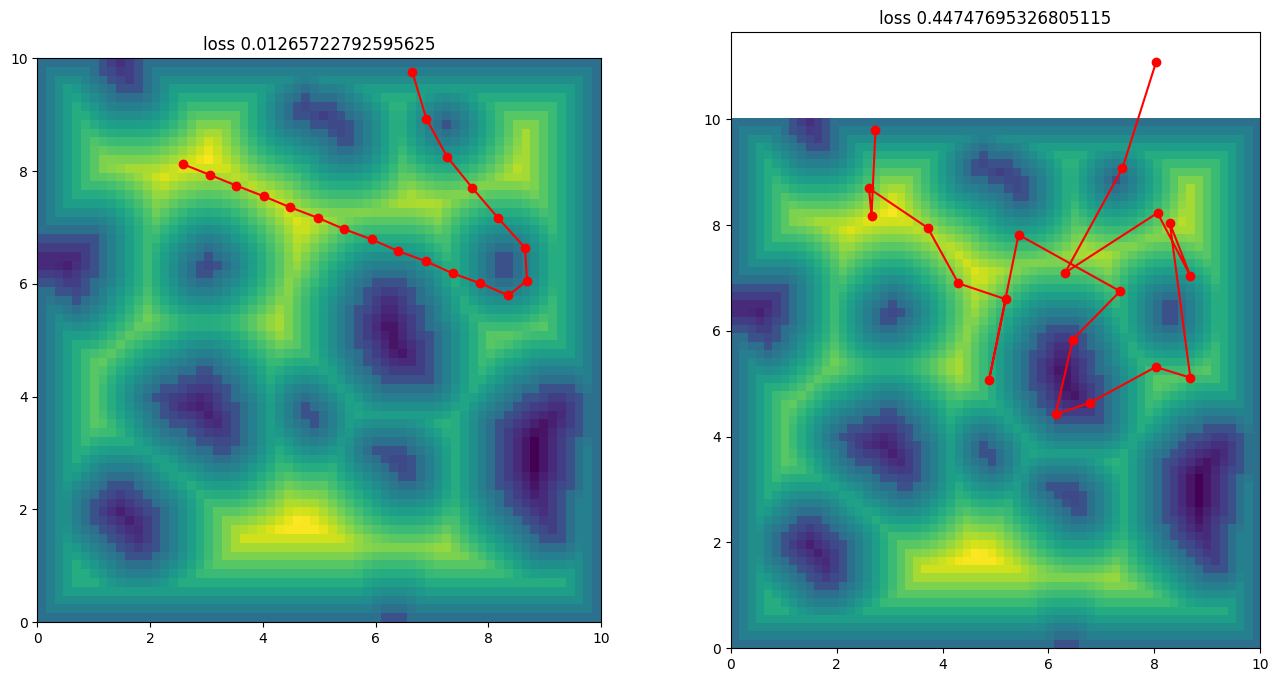

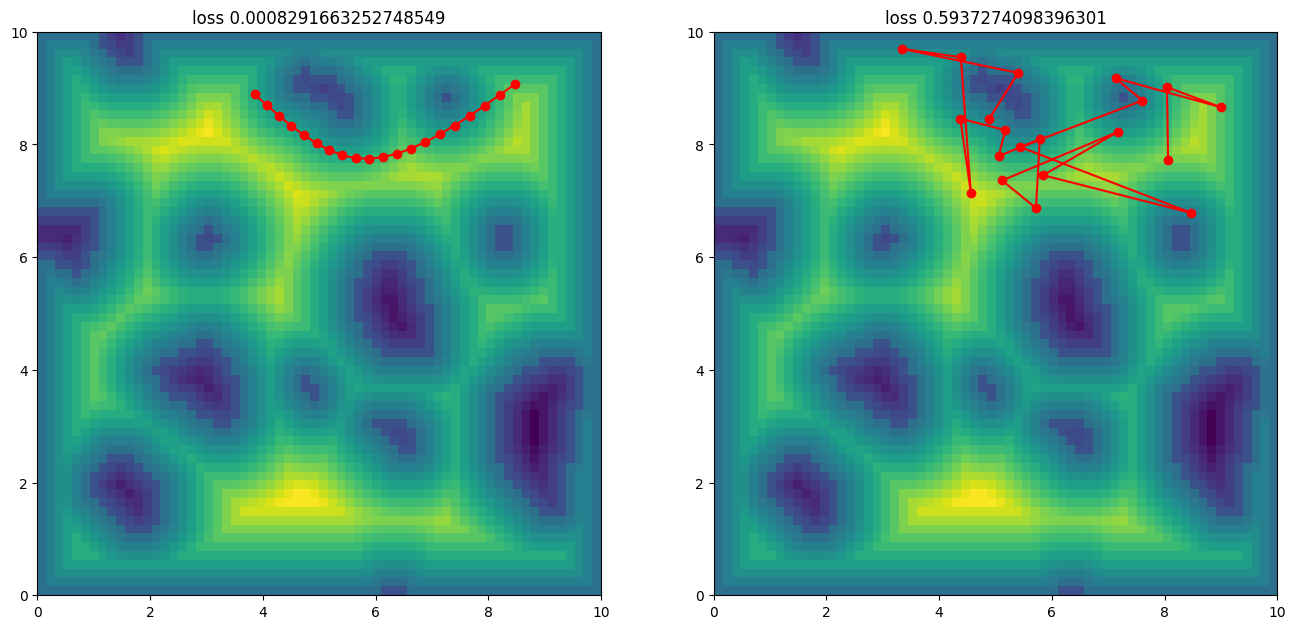

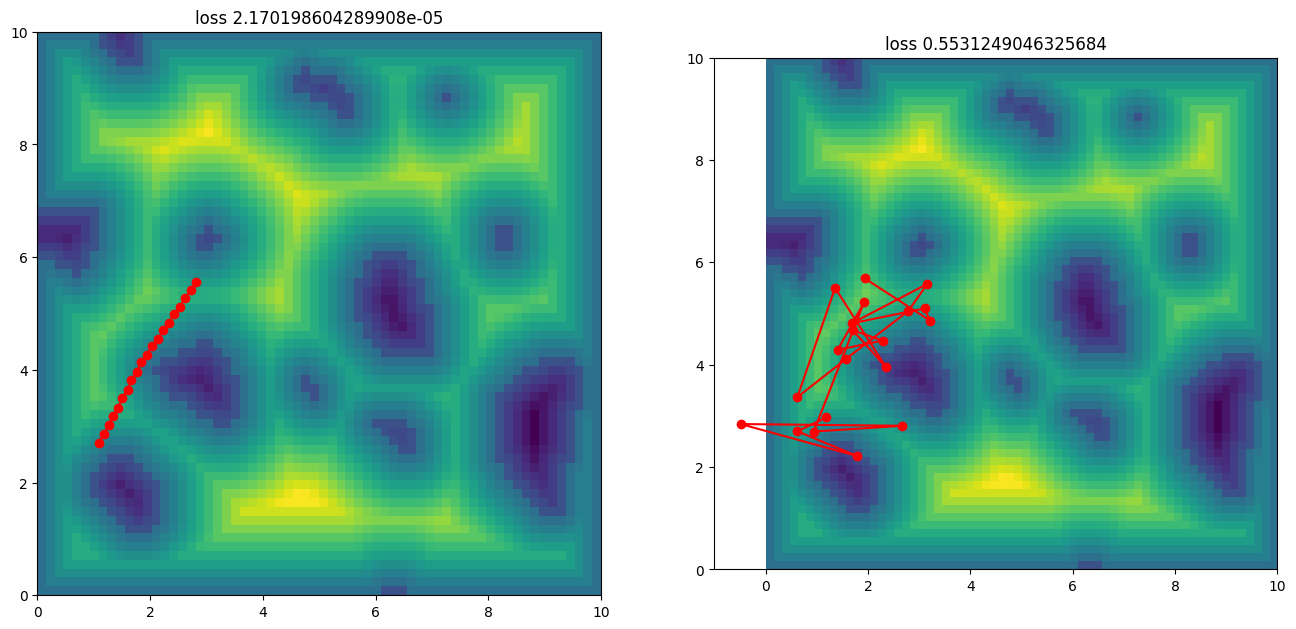

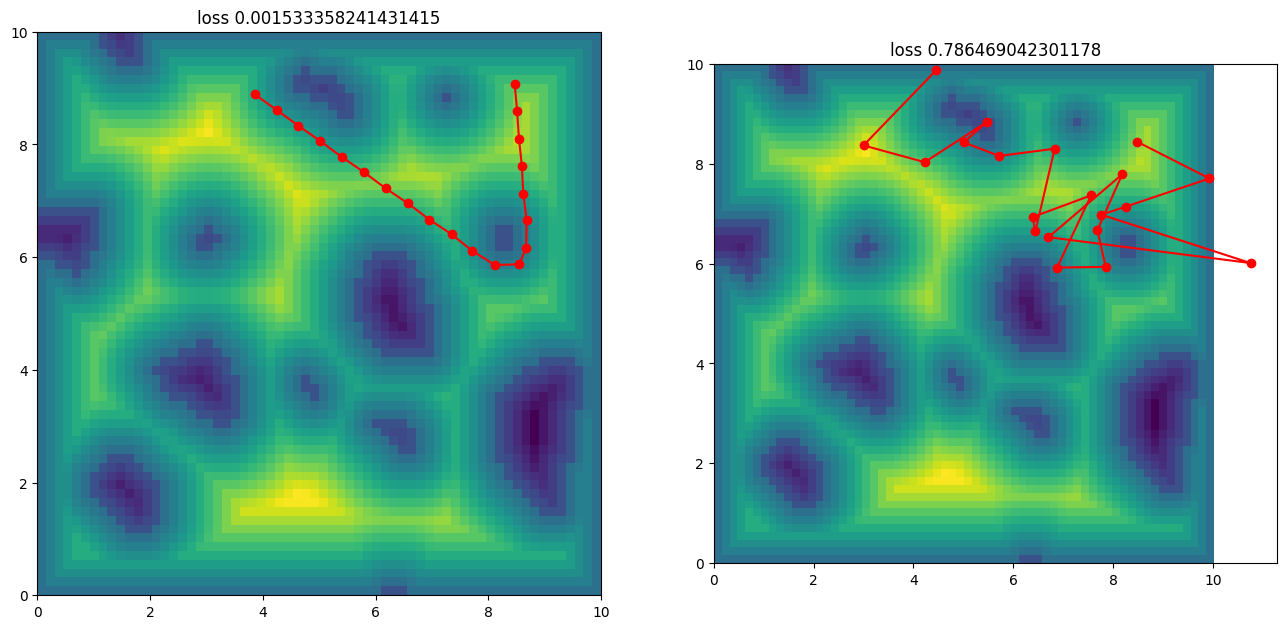

In [48]:
for i in range(10):
    # create a subpolt for 2 graphs
    fig, axs = plt.subplots(1, 2, figsize=(16, 8))
    # the 1st will be the path and its distance field + loss value 
    indx = np.random.randint(len(dataset))
    sample = dataset[indx]
    dimg = sample['world_distance_field_img'].to('cuda')
    path = sample['og_path']
    path = path.unsqueeze(0)
    dimg = dimg.unsqueeze(0)
    l = loss_fn(path)
    dimg = sample['world_distance_field_img']
    path = sample['og_path'].cpu().detach().numpy()
    axs[0].imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
    axs[0].plot(path[:, 0], path[:, 1], '-o', color='red')
    axs[0].set_title(f'loss {l}')
    # the 2nd will be the path + some noise and its distance field + loss value
    sample = dataset[indx]
    dimg = sample['world_distance_field_img'].to('cuda')
    path = sample['og_path']
    path = path.unsqueeze(0)
    dimg = dimg.unsqueeze(0)
    noise = torch.randn_like(path) * 0.8
    path = path + noise
    l = loss_fn(path)
    dimg = sample['world_distance_field_img']
    path = path.cpu().detach().numpy()
    axs[1].imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
    axs[1].plot(path[0, :, 0], path[0, :, 1], '-o', color='red')
    axs[1].set_title(f'loss {l}')